## Deep Learning Assignment

# Traffic Flow Prediction using LSTM

In [10]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [17]:
df=pd.read_csv("data/METR-LA.csv")

In [18]:
df.head()

,Unnamed: 0,773869,767541,767542,717447,717446,717445,773062,767620,737529,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
0,2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
1,2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2,2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
3,2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
4,2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [19]:
df=pd.read_csv("data/METR-LA.csv",index_col=0) #index_col=0 is done to make the first col becomes the dataframe index instead of an actual column


In [20]:
df.head()

,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [21]:

df.index=pd.to_datetime(df.index) #converst the first colum into date time so we can work with time series data (the first colum is timestamps)

In [22]:
df.head()

,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [23]:
df_original=df.copy() #to save the copy of the original data for comparision later on

In [24]:
print("Shape:", df.shape)

df.info()

Shape: (34272, 207)
<class 'pandas.DataFrame'>
DatetimeIndex: 34272 entries, 2012-03-01 00:00:00 to 2012-06-27 23:55:00
Columns: 207 entries, 773869 to 769373
dtypes: float64(207)
memory usage: 54.4 MB


In [25]:
df.describe()

,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
count,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,...,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000,34272.000000
mean,54.631359,60.452789,60.726120,49.524287,46.079798,50.952003,54.471684,57.255095,56.068044,52.871841,...,37.803342,58.156679,51.217523,59.795754,59.329923,56.915083,62.484679,54.697381,58.920210,51.197504
std,22.619199,15.970239,18.313353,15.843261,19.350345,16.681760,17.984761,18.751065,18.240361,23.343805,...,13.525743,20.690411,22.224997,16.126225,19.849950,18.260438,16.959238,16.303651,19.080474,21.239354
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.364583,63.000000,65.444444,50.333333,34.666667,49.555556,55.750000,61.000000,58.222222,43.428571,...,30.444444,64.111111,53.444444,61.714286,63.666667,60.222222,65.888889,50.125000,62.888889,54.125000
50%,64.888889,65.000000,67.375000,53.875000,46.000000,56.111111,62.111111,63.333333,62.444444,65.875000,...,43.222222,67.111111,61.777778,64.875000,66.777778,63.000000,67.625000,61.125000,66.125000,62.000000
75%,66.875000,66.375000,68.444444,58.125000,64.500000,60.333333,65.000000,65.000000,64.888889,67.625000,...,46.625000,68.444444,64.375000,66.500000,68.250000,64.750000,68.625000,64.444444,67.750000,63.444444
max,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,...,65.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000


In [26]:
df.isnull().sum().sum()

np.int64(0)

In [27]:
print("Columns:", len(df.columns))
print("Date Range:")
print(df.index.min())
print(df.index.max())

Columns: 207
Date Range:
2012-03-01 00:00:00
2012-06-27 23:55:00


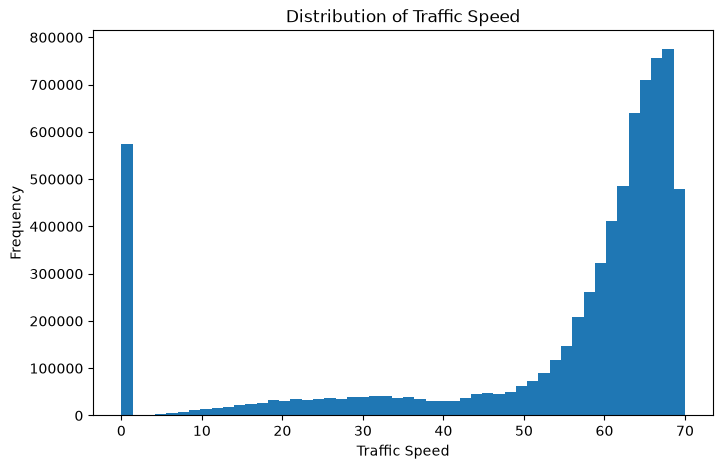

In [28]:
#Histogram - to understand how traffic values are distributed
plt.figure(figsize=(8,5))
plt.hist(df.values.flatten(),bins=50) #Converts the entire dataset into one long list of values,so that all sensor readings are included in the histogram
plt.title("Distribution of Traffic Speed")
plt.xlabel("Traffic Speed")
plt.ylabel("Frequency")
plt.show()

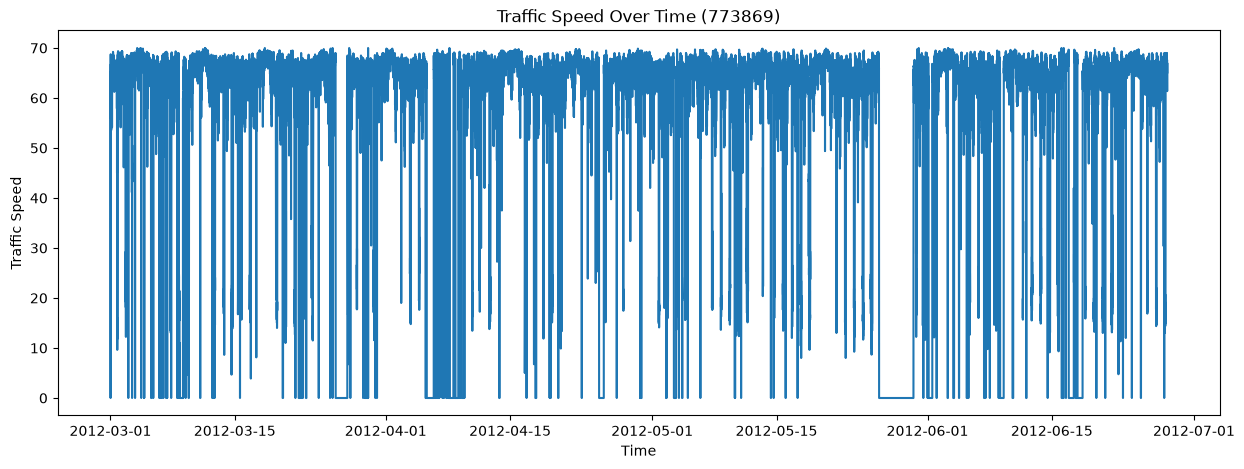

In [29]:
#Visualizeing how traffic changes over time for one sensor
sensor=df.columns[0] #selection only one sensor and showinh its data
plt.figure(figsize=(15,5))
plt.plot(df[sensor])
plt.title(f"Traffic Speed Over Time ({sensor})")
plt.xlabel("Time")
plt.ylabel("Traffic Speed")
plt.show()

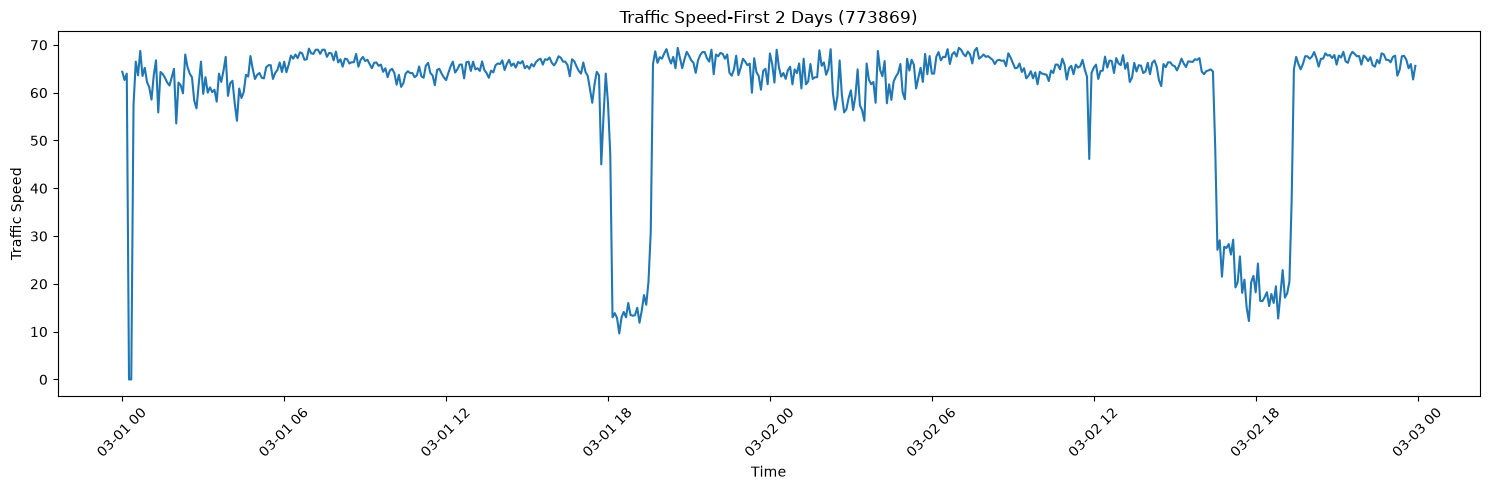

In [30]:
sensor=df.columns[0]
subset=df.iloc[:576]#576 readings=2 days(5-minute intervals in each reading)
plt.figure(figsize=(15,5))
plt.plot(subset.index, subset[sensor])
plt.title(f"Traffic Speed-First 2 Days ({sensor})")
plt.xlabel("Time")
plt.ylabel("Traffic Speed")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

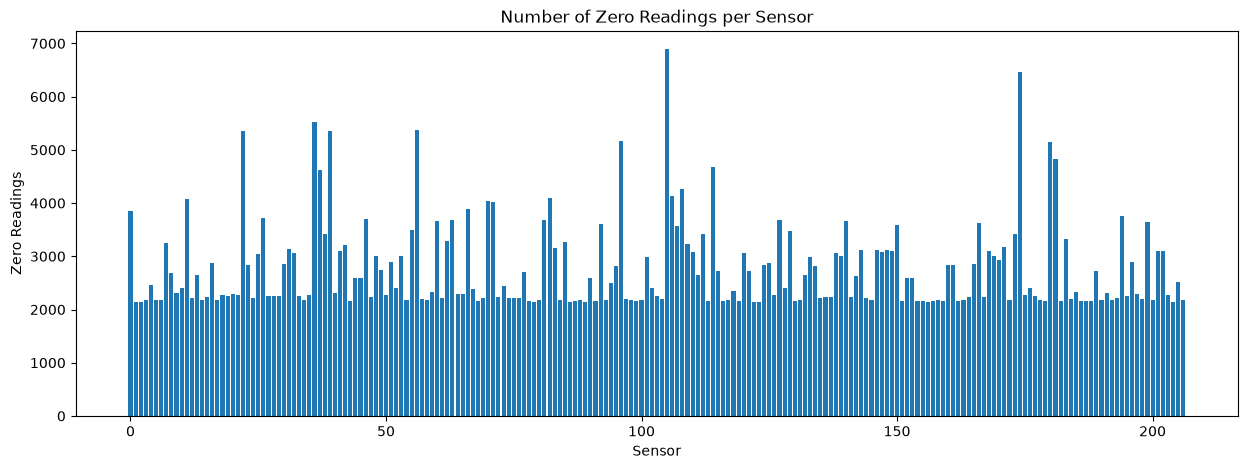

In [31]:
#zero value alalysis
zero_counts=(df==0).sum()
plt.figure(figsize=(15,5))
plt.bar(range(len(zero_counts)), zero_counts)
plt.title("Number of Zero Readings per Sensor")
plt.xlabel("Sensor")
plt.ylabel("Zero Readings")
plt.show()

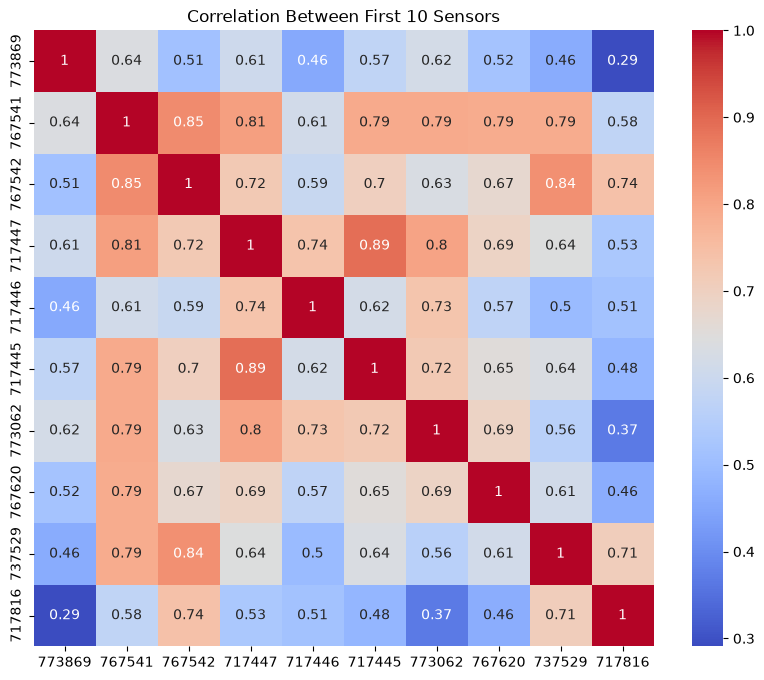

In [32]:
#correlation of values between the 10 neabouring sensors
plt.figure(figsize=(10,8))
sns.heatmap(
    df.iloc[:, :10].corr(), 
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Between First 10 Sensors")
plt.show()

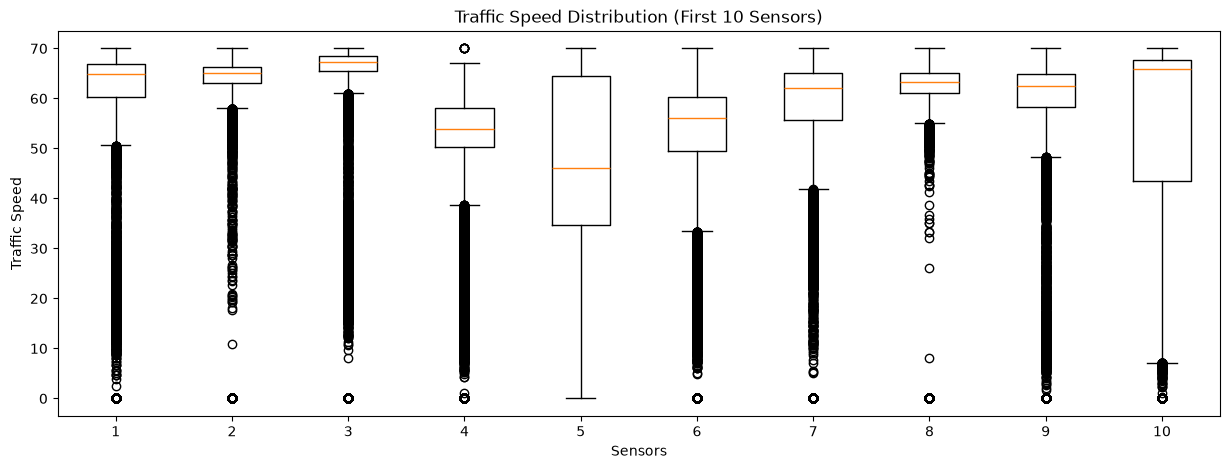

In [34]:
plt.figure(figsize=(15,5))
plt.boxplot(df.iloc[:,:10].values)
plt.title("Traffic Speed Distribution (First 10 Sensors)")
plt.xlabel("Sensors")
plt.ylabel("Traffic Speed")
plt.show()

In [35]:
#total count of zero values in the data set
zero_count=(df==0).sum().sum()
print("Total Zero Values:",zero_count)

Total Zero Values: 575302


In [36]:
#timestapm at which every sensor recorded a 0 value
all_zero_rows=(df==0).all(axis=1)
print("Rows where every sensor is zero:",all_zero_rows.sum())
df[all_zero_rows].head()

Rows where every sensor is zero: 2148


,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012-03-01 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012-03-03 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012-03-05 13:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2012-03-05 13:35:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
#replacing zerovalues as nan to treatthen as missing values
df.replace(0,np.nan,inplace=True)

df.interpolate(method="time",inplace=True)

df.ffill(inplace=True)
df.bfill(inplace=True)
#'inplace=True' modifies the existing data frame instead of creating a new one

,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125000,67.125000,59.625000,62.750000,...,45.625000,65.500000,64.500000,66.428571,66.875000,59.375000,69.000000,59.250000,69.000000,61.875000
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000000,65.000000,57.444444,63.333333,...,50.666667,69.875000,66.666667,58.555556,62.000000,61.111111,64.444444,55.888889,68.444444,62.875000
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500000,64.250000,63.875000,65.375000,...,44.125000,69.000000,56.500000,59.250000,68.125000,62.500000,65.625000,61.375000,69.857143,62.000000
2012-03-01 00:15:00,61.777778,65.500000,62.555556,59.888889,66.777778,67.166667,63.222222,65.277778,63.583333,64.694444,...,43.416667,69.333333,60.444444,58.611111,67.416667,59.888889,65.305556,60.138889,69.571429,60.444444
2012-03-01 00:20:00,59.555556,67.250000,65.111111,60.777778,67.055556,68.083333,61.944444,66.305556,63.291667,64.013889,...,42.708333,69.666667,64.388889,57.972222,66.708333,57.277778,64.986111,58.902778,69.285714,58.888889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-06-27 23:35:00,65.000000,65.888889,68.555556,61.666667,32.833333,54.555556,62.444444,63.333333,59.222222,65.333333,...,52.888889,69.000000,65.111111,55.666667,66.333333,62.444444,66.777778,64.888889,69.666667,62.333333
2012-06-27 23:40:00,61.375000,65.625000,66.500000,62.750000,32.833333,50.500000,62.000000,67.000000,65.250000,67.125000,...,54.000000,69.250000,60.125000,60.500000,67.250000,59.375000,66.000000,61.250000,69.000000,62.000000
2012-06-27 23:45:00,67.000000,59.666667,69.555556,61.000000,32.833333,44.777778,64.222222,63.777778,59.777778,57.666667,...,51.333333,67.888889,64.333333,57.000000,66.000000,62.666667,68.666667,63.333333,67.444444,61.222222
2012-06-27 23:50:00,66.750000,62.250000,66.000000,59.625000,32.833333,53.000000,64.285714,64.125000,60.875000,66.250000,...,51.125000,69.375000,61.625000,60.500000,65.625000,66.375000,69.500000,63.000000,67.875000,63.500000


In [38]:
print("Remaining Missing Values:",df.isnull().sum().sum())
print("Remaining Zero Values:",(df == 0).sum().sum())

Remaining Missing Values: 0
Remaining Zero Values: 0


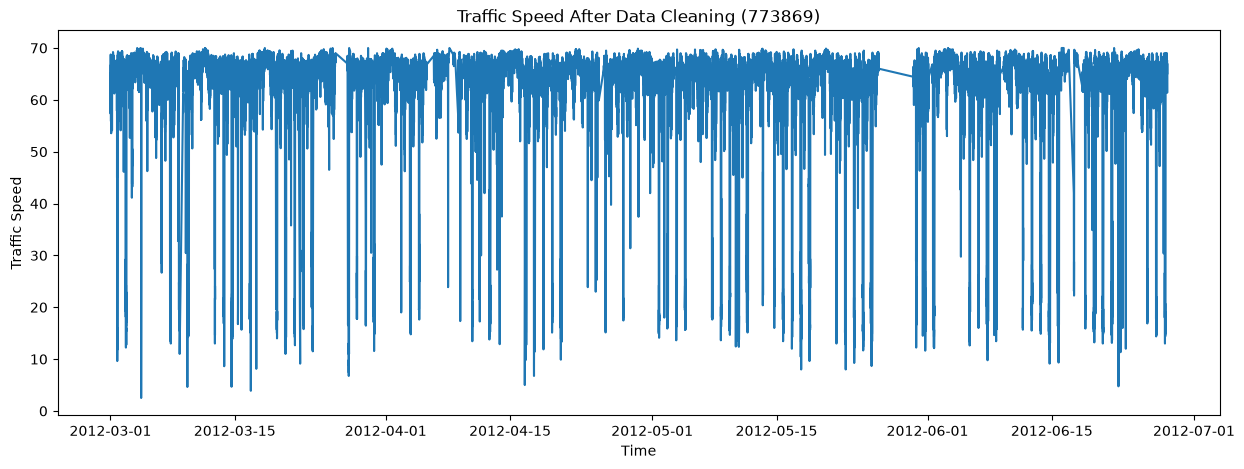

In [39]:
plt.figure(figsize=(15,5))
plt.plot(df[sensor])
plt.title(f"Traffic Speed After Data Cleaning ({sensor})")
plt.xlabel("Time")
plt.ylabel("Traffic Speed")
plt.show()

In [40]:
#two variable sensoe and traffic_data
sensor=df.columns[0]
traffic_data=df[sensor]
print("Selected Sensor:", sensor)

Selected Sensor: 773869


In [41]:
#Normalizing the traffic data so all values lie btw 0-1
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(
    traffic_data.values.reshape(-1, 1)
)
print(scaled_data[:5])

[[0.91666667]
 [0.89135802]
 [0.91111111]
 [0.8781893 ]
 [0.84526749]]


In [42]:
#Number of previous time steps used for prediction
sequence_length=10

In [43]:
#Creating empty lists to store inputs(X) and targets(y)
X=[]
y=[]

#loop starts from the 10th reading because we need the previous 10 values before making the first prediction.
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i,0])
    y.append(scaled_data[i,0])
    
# Convert lists to NumPy arrays
X = np.array(X)
y = np.array(y)

In [44]:
print("X shape:",X.shape)
print("y shape:",y.shape)

#there are 34,262 training samples,and each sample contains 10 previous traffic readings

X shape: (34262, 10)
y shape: (34262,)


In [45]:
#Converting the data into the format expected by the LSTM
X=X.reshape((X.shape[0], X.shape[1], 1))
print("New X shape:", X.shape)

New X shape: (34262, 10, 1)


In [46]:
print("First Input Sequence:")
print(X[0])
print("Target Value:")
print(y[0])

First Input Sequence:
[[0.91666667]
 [0.89135802]
 [0.91111111]
 [0.8781893 ]
 [0.84526749]
 [0.81234568]
 [0.94814815]
 [0.90555556]
 [0.98148148]
 [0.9037037 ]]
Target Value:
0.9292181069958849


In [47]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=False)
#shuffle is set to false because this is a time series data and we can not manipulate it as we wish

In [48]:
#building the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(Dense(units=1))

d:\Traffic-Flow-Prediction-LSTM\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [49]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [51]:
history=model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - loss: 0.0194 - val_loss: 0.0066
Epoch 2/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 0.0086 - val_loss: 0.0050
Epoch 3/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.0071 - val_loss: 0.0043
Epoch 4/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - loss: 0.0060 - val_loss: 0.0041
Epoch 5/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0052 - val_loss: 0.0037
Epoch 6/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0046 - val_loss: 0.0035
Epoch 7/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.0041 - val_loss: 0.0038
Epoch 8/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0038 - val_loss: 0.0034
Epoch 9/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0036 - val_loss: 0.0033
Epoch 10/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0034 - val_loss: 0.0034


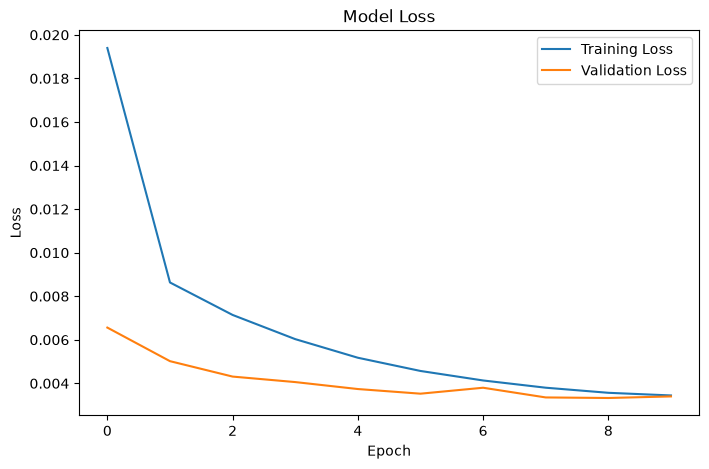

In [52]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [53]:
predictions=model.predict(X_test)

215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [54]:
#the model predicts normalized values,not the original traffic speeds
predictions=scaler.inverse_transform(predictions)

In [55]:

#Again converting the array into the 2D format expected by Scikit-learn
actual=scaler.inverse_transform(y_test.reshape(-1, 1))

In [56]:
#evalution matrices
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae=mean_absolute_error(actual,predictions)
rmse=np.sqrt(mean_squared_error(actual,predictions))
print("MAE :",mae)
print("RMSE:",rmse)

MAE : 1.986931527873808
RMSE: 3.9357692326274054


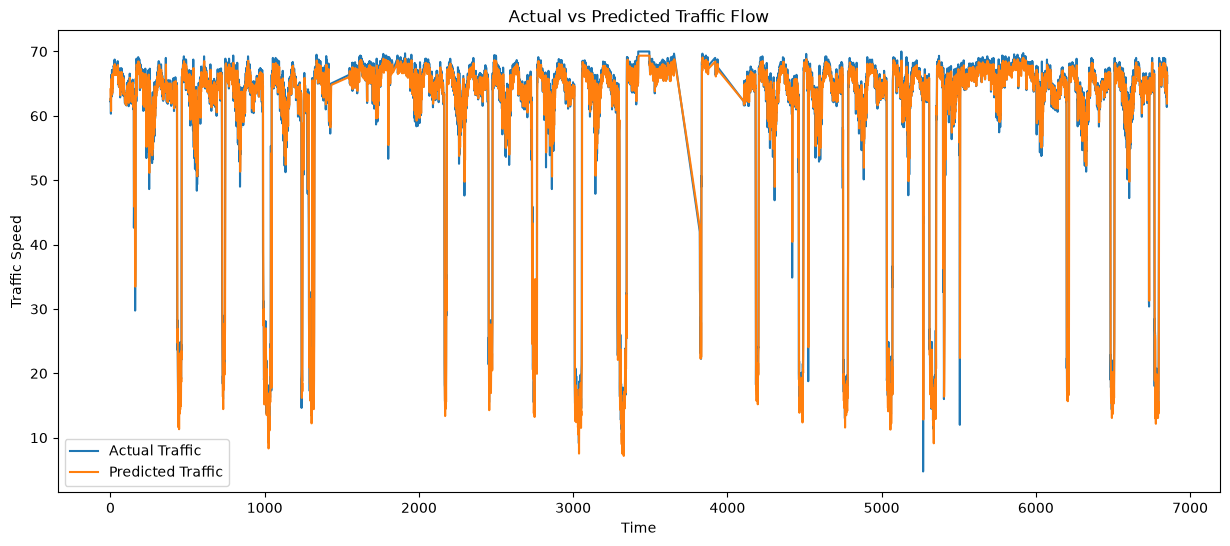

In [57]:
plt.figure(figsize=(15,6))
plt.plot(actual, label="Actual Traffic")
plt.plot(predictions, label="Predicted Traffic")
plt.title("Actual vs Predicted Traffic Flow")
plt.xlabel("Time")
plt.ylabel("Traffic Speed")
plt.legend()
plt.show()

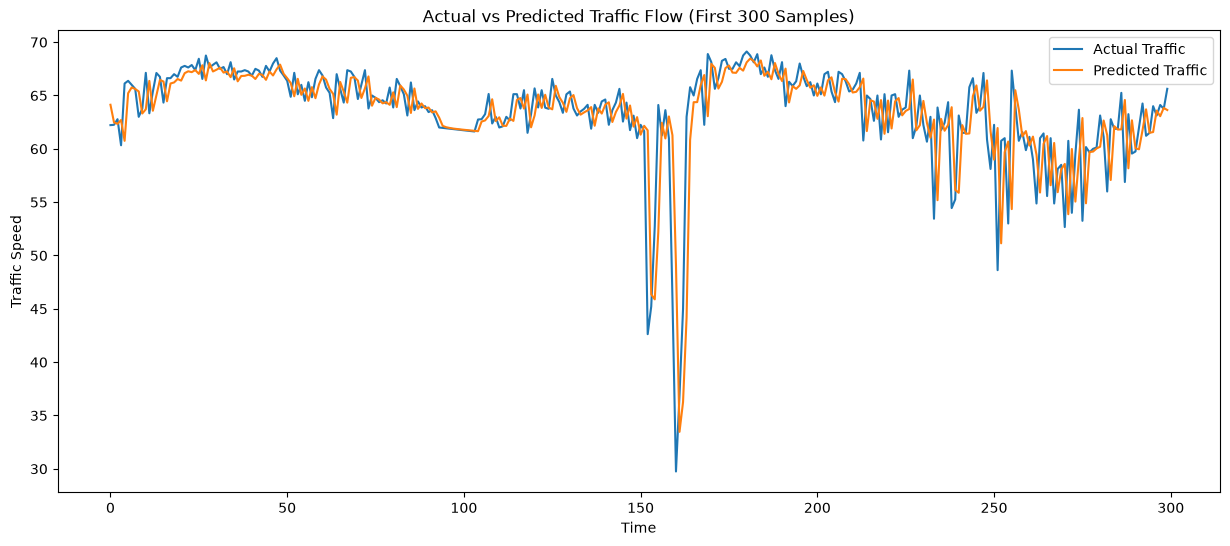

In [58]:

plt.figure(figsize=(15,6))
plt.plot(actual[:300], label="Actual Traffic")
plt.plot(predictions[:300], label="Predicted Traffic")
plt.title("Actual vs Predicted Traffic Flow (First 300 Samples)")
plt.xlabel("Time")
plt.ylabel("Traffic Speed")
plt.legend()
plt.show()

In [59]:
import os
os.makedirs("models",exist_ok=True)
model.save("models/traffic_lstm.keras")
print("Model saved successfully")

Model saved successfully


In [60]:
import joblib

joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']